<a href="https://colab.research.google.com/github/harshkumar0901/Colab/blob/main/CIFAR_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install kaggle

In [ ]:
#Upload kaggle.json file
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"harsh56kumar","key":"aaa38daff8751f679df5ab9406fe22b0"}'}

In [ ]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!ls -ltr ~/.kaggle

total 4
-rw------- 1 root root 68 May 20 01:41 kaggle.json


To download a Kaggle dataset, you'll need its identifier, which is typically in the format `owner/dataset-name`. For example, for the 'Titanic - Machine Learning from Disaster' dataset, the identifier is `titanic/titanic`.

Please enter the dataset identifier in the code cell below:

In [ ]:
import kaggle
import zipfile
import os

# Replace 'dataset-identifier' with the actual dataset identifier you want to download
dataset_identifier = "ayush1220/cifar10/" # @param {type:"string"}

try:
    if dataset_identifier:
        print(f"Downloading dataset: {dataset_identifier}")
        kaggle.api.dataset_download_files(dataset_identifier, path='./', unzip=False)

        # Unzip all downloaded files
        for file in os.listdir('./'):
            if file.endswith('.zip'):
                with zipfile.ZipFile(file, 'r') as zip_ref:
                    zip_ref.extractall('./')
                print(f"Unzipped: {file}")
                os.remove(file)
    else:
        print("Please provide a dataset identifier.")

    print("Downloaded and unzipped files:")
    !ls -lh

except NameError as e:
    if "name 'exit' is not defined" in str(e):
        print("\n--- ERROR ---")
        print("Kaggle authentication failed. Please ensure your `kaggle.json` file is correctly uploaded to `~/.kaggle/` and has `chmod 600` permissions.")
        print("You might need to re-run the cells for uploading `kaggle.json` and setting permissions.")
        print("---------------")
    else:
        raise e # Re-raise other NameErrors

Dataset URL: https://www.kaggle.com/datasets/ayush1220/cifar10/versions/
Unzipped: cifar10.zip
Downloaded and unzipped files:
total 8.0K
drwxr-xr-x 4 root root 4.0K May 20 01:31 cifar10
drwxr-xr-x 1 root root 4.0K May 12 13:35 sample_data


In [ ]:
!ls -l cifar10/

total 8
drwxr-xr-x 12 root root 4096 May 20 01:31 test
drwxr-xr-x 12 root root 4096 May 20 01:31 train


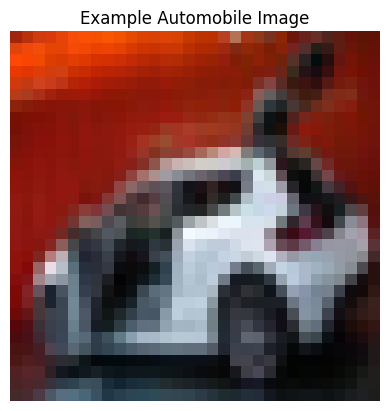

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import os

# Path to the example image
image_path = os.path.join('cifar10', 'test', 'automobile', '0001.png')

# Load the image
image = Image.open(image_path)

# Display the image
plt.imshow(image)
plt.title('Example Automobile Image')
plt.axis('off') # Hide axes ticks and labels
plt.show()

In [ ]:
!ls -l cifar10/test/

total 280
drwxr-xr-x 2 root root 28672 May 20 01:31 airplane
drwxr-xr-x 2 root root 28672 May 20 01:31 automobile
drwxr-xr-x 2 root root 28672 May 20 01:31 bird
drwxr-xr-x 2 root root 28672 May 20 01:31 cat
drwxr-xr-x 2 root root 28672 May 20 01:31 deer
drwxr-xr-x 2 root root 28672 May 20 01:31 dog
drwxr-xr-x 2 root root 28672 May 20 01:31 frog
drwxr-xr-x 2 root root 28672 May 20 01:31 horse
drwxr-xr-x 2 root root 28672 May 20 01:31 ship
drwxr-xr-x 2 root root 28672 May 20 01:31 truck


In [5]:
import pandas as pd
import numpy as np
import matplotlib.image as mpimg
from sklearn.model_selection import train_test_split

In [6]:
filenames = os.listdir('cifar10/test')

In [7]:
type(filenames)

list

In [8]:
print(filenames[0:5])

['automobile', 'dog', 'bird', 'ship', 'cat']


In [9]:
print(filenames[-5:])

['deer', 'truck', 'airplane', 'frog', 'horse']


**Labels Processing**

In [12]:
import os

def create_labels_df(base_dir):
    image_id = []
    labels = []
    for class_name in os.listdir(base_dir):
        class_path = os.path.join(base_dir, class_name)
        if os.path.isdir(class_path):
            for img_name in os.listdir(class_path):
                # Extract the numeric part of the filename for 'id'
                # Assuming format like '0001.png', '12345.png'
                image_id.append(int(img_name.split('.')[0]))
                labels.append(class_name)

    df = pd.DataFrame({'id': image_id, 'label': labels})
    df = df.sort_values(by='id').reset_index(drop=True)
    return df

labels_df = create_labels_df('cifar10/train')
display(labels_df.head())

,id,label
0,1,truck
1,1,horse
2,1,bird
3,1,cat
4,1,ship


In [11]:
!ls -l cifar10/train

total 1360
drwxr-xr-x 2 root root 135168 May 20 01:31 airplane
drwxr-xr-x 2 root root 135168 May 20 01:31 automobile
drwxr-xr-x 2 root root 135168 May 20 01:31 bird
drwxr-xr-x 2 root root 135168 May 20 01:31 cat
drwxr-xr-x 2 root root 135168 May 20 01:31 deer
drwxr-xr-x 2 root root 135168 May 20 01:31 dog
drwxr-xr-x 2 root root 135168 May 20 01:31 frog
drwxr-xr-x 2 root root 135168 May 20 01:31 horse
drwxr-xr-x 2 root root 135168 May 20 01:31 ship
drwxr-xr-x 2 root root 135168 May 20 01:31 truck


In [13]:
labels_df.shape

(50000, 2)

In [19]:
labels_df.iloc[:11]

,id,label
0,1,truck
1,1,horse
2,1,bird
3,1,cat
4,1,ship
5,1,frog
6,1,dog
7,1,automobile
8,1,deer
9,1,airplane


### Prepare Data for Training

In [20]:
train_dir = 'cifar10/train'

# Function to get the full image path
def get_image_path(row, base_dir):
    # Reconstruct the class_name from the 'label' column
    class_name = row['label']
    # Reconstruct the filename from the 'id' column
    filename = f"{row['id']:04d}.png" # Ensure leading zeros if necessary
    return os.path.join(base_dir, class_name, filename)

# Apply the function to create a new 'path' column
labels_df['path'] = labels_df.apply(lambda row: get_image_path(row, train_dir), axis=1)

print("Labels DataFrame with image paths:")
display(labels_df.head())

Labels DataFrame with image paths:


,id,label,path
0,1,truck,cifar10/train/truck/0001.png
1,1,horse,cifar10/train/horse/0001.png
2,1,bird,cifar10/train/bird/0001.png
3,1,cat,cifar10/train/cat/0001.png
4,1,ship,cifar10/train/ship/0001.png


In [21]:
from sklearn.preprocessing import LabelEncoder

# Encode labels
le = LabelEncoder()
labels_df['label_encoded'] = le.fit_transform(labels_df['label'])

print("Labels and their corresponding encoded values:")
for i, label in enumerate(le.classes_):
    print(f"{label}: {i}")

print("\nLabels DataFrame with encoded labels:")
display(labels_df.head())

Labels and their corresponding encoded values:
airplane: 0
automobile: 1
bird: 2
cat: 3
deer: 4
dog: 5
frog: 6
horse: 7
ship: 8
truck: 9

Labels DataFrame with encoded labels:


,id,label,path,label_encoded
0,1,truck,cifar10/train/truck/0001.png,9
1,1,horse,cifar10/train/horse/0001.png,7
2,1,bird,cifar10/train/bird/0001.png,2
3,1,cat,cifar10/train/cat/0001.png,3
4,1,ship,cifar10/train/ship/0001.png,8


In [27]:
# Printing the 3-channel array form of the images
img_path = labels_df['path'][0]
img = mpimg.imread(img_path)
print(img)

[[[0.6039216  0.69411767 0.73333335]
  [0.49411765 0.5372549  0.53333336]
  [0.4117647  0.40784314 0.37254903]
  ...
  [0.35686275 0.37254903 0.2784314 ]
  [0.34117648 0.3529412  0.2784314 ]
  [0.30980393 0.31764707 0.27450982]]

 [[0.54901963 0.627451   0.6627451 ]
  [0.5686275  0.6        0.6039216 ]
  [0.49019608 0.49019608 0.4627451 ]
  ...
  [0.3764706  0.3882353  0.30588236]
  [0.3019608  0.3137255  0.24313726]
  [0.2784314  0.28627452 0.23921569]]

 [[0.54901963 0.60784316 0.6431373 ]
  [0.54509807 0.57254905 0.58431375]
  [0.4509804  0.4509804  0.4392157 ]
  ...
  [0.30980393 0.32156864 0.2509804 ]
  [0.26666668 0.27450982 0.21568628]
  [0.2627451  0.27058825 0.21568628]]

 ...

 [[0.6862745  0.654902   0.6509804 ]
  [0.6117647  0.6039216  0.627451  ]
  [0.6039216  0.627451   0.6666667 ]
  ...
  [0.16470589 0.13333334 0.14117648]
  [0.23921569 0.20784314 0.22352941]
  [0.3647059  0.3254902  0.35686275]]

 [[0.64705884 0.6039216  0.5019608 ]
  [0.6117647  0.59607846 0.50980395]


In [22]:
X = labels_df['path']
y = labels_df['label_encoded']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training images: {len(X_train)}")
print(f"Validation images: {len(X_val)}")

# Display the first few training paths and labels
print("\nFirst 5 training paths and labels:")
for i in range(5):
    print(f"Path: {X_train.iloc[i]}, Label: {y_train.iloc[i]}")

Training images: 40000
Validation images: 10000

First 5 training paths and labels:
Path: cifar10/train/frog/0324.png, Label: 6
Path: cifar10/train/horse/4671.png, Label: 7
Path: cifar10/train/ship/4027.png, Label: 8
Path: cifar10/train/cat/3332.png, Label: 3
Path: cifar10/train/bird/1519.png, Label: 2


### Create Data Generators

In [29]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Image dimensions
IMG_WIDTH = 32
IMG_HEIGHT = 32
BATCH_SIZE = 32

# Create a DataFrame for training and validation paths and encoded labels
train_df = pd.DataFrame({'path': X_train, 'label_encoded': y_train})
val_df = pd.DataFrame({'path': X_val, 'label_encoded': y_val})

# Convert encoded labels back to strings for the flow_from_dataframe method
# ImageDataGenerator's flow_from_dataframe expects string labels for 'class_mode="categorical"'
train_df['label'] = le.inverse_transform(train_df['label_encoded'])
val_df['label'] = le.inverse_transform(val_df['label_encoded'])

# Training Data Generator with Augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255, # Normalize pixel values to [0, 1]
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Validation Data Generator (only rescaling, no augmentation)
val_datagen = ImageDataGenerator(rescale=1./255)

# Create iterators for training and validation data
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='path',
    y_col='label',
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=42
)

val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='path',
    y_col='label',
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False, # No need to shuffle validation data
    seed=42
)

print("\nData generators created successfully!")

Found 40000 validated image filenames belonging to 10 classes.
Found 10000 validated image filenames belonging to 10 classes.

Data generators created successfully!


In [28]:
print(X_train.shape)

(40000,)


### Define the CNN Model Architecture

In [31]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Get the number of classes from the generator
num_classes = len(train_generator.class_indices)

# Define the CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_WIDTH, IMG_HEIGHT, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax') # Output layer with num_classes for classification
])

# Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,202 (625.79 KB)

 Trainable params: 160,202 (625.79 KB)

 Non-trainable params: 0 (0.00 B)

### Train the Model

In [32]:
EPOCHS = 10 # You can adjust the number of epochs

history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=val_generator,
    validation_steps=val_generator.samples // BATCH_SIZE
)

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 50s 35ms/step - accuracy: 0.2898 - loss: 1.8922 - val_accuracy: 0.4371 - val_loss: 1.5408
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 44s 35ms/step - accuracy: 0.4029 - loss: 1.6336 - val_accuracy: 0.4858 - val_loss: 1.4229
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 81s 65ms/step - accuracy: 0.4526 - loss: 1.5165 - val_accuracy: 0.5514 - val_loss: 1.2353
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 42s 34ms/step - accuracy: 0.4866 - loss: 1.4353 - val_accuracy: 0.5358 - val_loss: 1.2735
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 44s 35ms/step - accuracy: 0.5113 - loss: 1.3851 - val_accuracy: 0.5892 - val_loss: 1.1566
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 81s 34ms/step - accuracy: 0.5265 - loss: 1.3351 - val_accuracy: 0.5786 - val_loss: 1.1917
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 44s 35ms/step - accuracy: 0.5387 - loss: 1.3108 - val_accuracy: 0.6084 - val_loss: 1.0727
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 43s 34ms/step - accuracy: 0.5561 -

### Evaluate and Visualize Training History

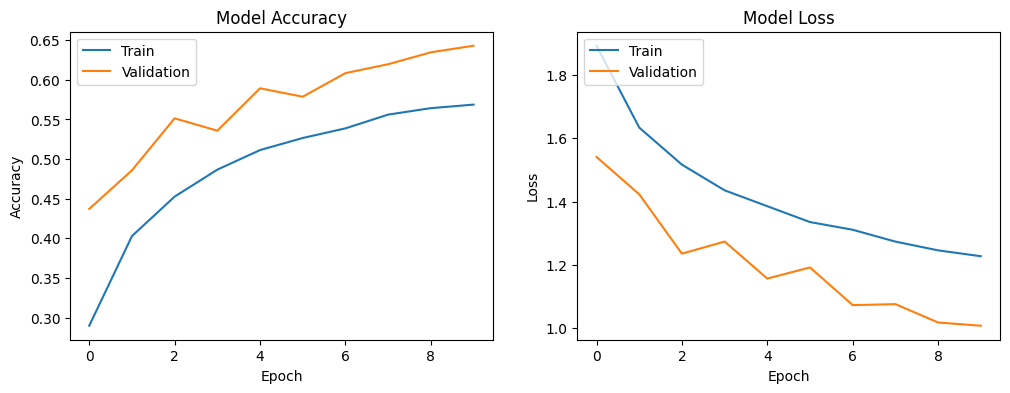

In [33]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

### Save the Trained Model

After training, it's crucial to save your model so you don't have to retrain it every time you want to use it. Keras models can be saved in the TensorFlow SavedModel format or H5 format. The SavedModel format is generally recommended.


In [35]:
import os

# Define a path to save the model
model_save_path = 'cifar10_cnn_model.keras'

# Save the model in the TensorFlow SavedModel format
model.save(model_save_path)
print(f"Model saved to: {model_save_path}")

# You can also save it as an H5 file (optional)
# model.save('cifar10_cnn_model.h5')
# print("Model saved as cifar10_cnn_model.h5")

Model saved to: cifar10_cnn_model.keras


### How to Use the Saved Model with a Frontend

Once your model is saved, you do **not** need to retrain it when you want to use it with a frontend. Instead, you'll load the saved model.

Here's the general workflow:

1.  **Backend Application:** You'll typically have a backend application (e.g., using Flask, FastAPI, or Node.js with TensorFlow.js for Node) that handles loading the model and making predictions.

2.  **Load the Model in the Backend:** In your backend, you would load the model like this:

    ```python
    from tensorflow.keras.models import load_model

    # Load the model from the saved path
    loaded_model = load_model('cifar10_cnn_model')
    print("Model loaded successfully!")
    ```

3.  **Create an API Endpoint:** The backend would expose an API endpoint (e.g., `/predict`) where your frontend can send image data.

4.  **Frontend Interaction:**
    *   Your frontend (e.g., in VS Code with HTML/CSS/JavaScript, React, Vue) allows the user to upload an image.
    *   The frontend sends this image data to your backend's `/predict` API endpoint.

5.  **Backend Prediction:**
    *   The backend receives the image.
    *   It preprocesses the image (resizing, normalizing pixel values) to match the input format your CNN expects.
    *   It uses `loaded_model.predict()` to get the classification results.
    *   It converts the numerical predictions back into human-readable labels (using your `LabelEncoder` or a stored mapping).
    *   It sends these results back to the frontend.

6.  **Frontend Display:** The frontend receives the prediction results and displays them to the user.

**To summarize:** You only train the model once until you decide to improve it. For deployment with a frontend, you save the trained model and then load it into a backend service that serves predictions to your frontend. So no, you don't have to retrain the model after your frontend task is done. You just load the model you've already trained and saved.